# Signal Composition and Frequency Analysis

**Author:** Santhosh RK  
**Institution:** PSG College of Technology  
**Date:** 04.04.26

## Overview
This notebook demonstrates how real-world signals are composed 
of multiple frequency components, how the FFT reveals hidden 
frequency content, and how digital filters selectively remove 
unwanted components.

**Key concepts covered:**
- Composite signal generation
- FFT frequency analysis  
- Low-pass digital filtering
- SNR measurement

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, freqz,filtfilt

In [2]:
fs=1000
time=1
t=np.linspace(0,time,fs)

print(f"Sampling rate:{fs}")
print(f"Duration :{time}")
print(f"Total samples:{len(t)}")
print(f"Frequency resolution: {fs/len(t)}")

Sampling rate:1000
Duration :1
Total samples:1000
Frequency resolution: 1.0


## Step 1: Building a Composite Signal

Real-world signals are rarely pure sine waves. An ECG contains 
heartbeat frequencies (1–40 Hz), motion artifacts (0.1–1 Hz), 
and powerline interference (50 Hz in India).

Here we simulate this by combining three sine waves at different 
frequencies, then adding random Gaussian noise.

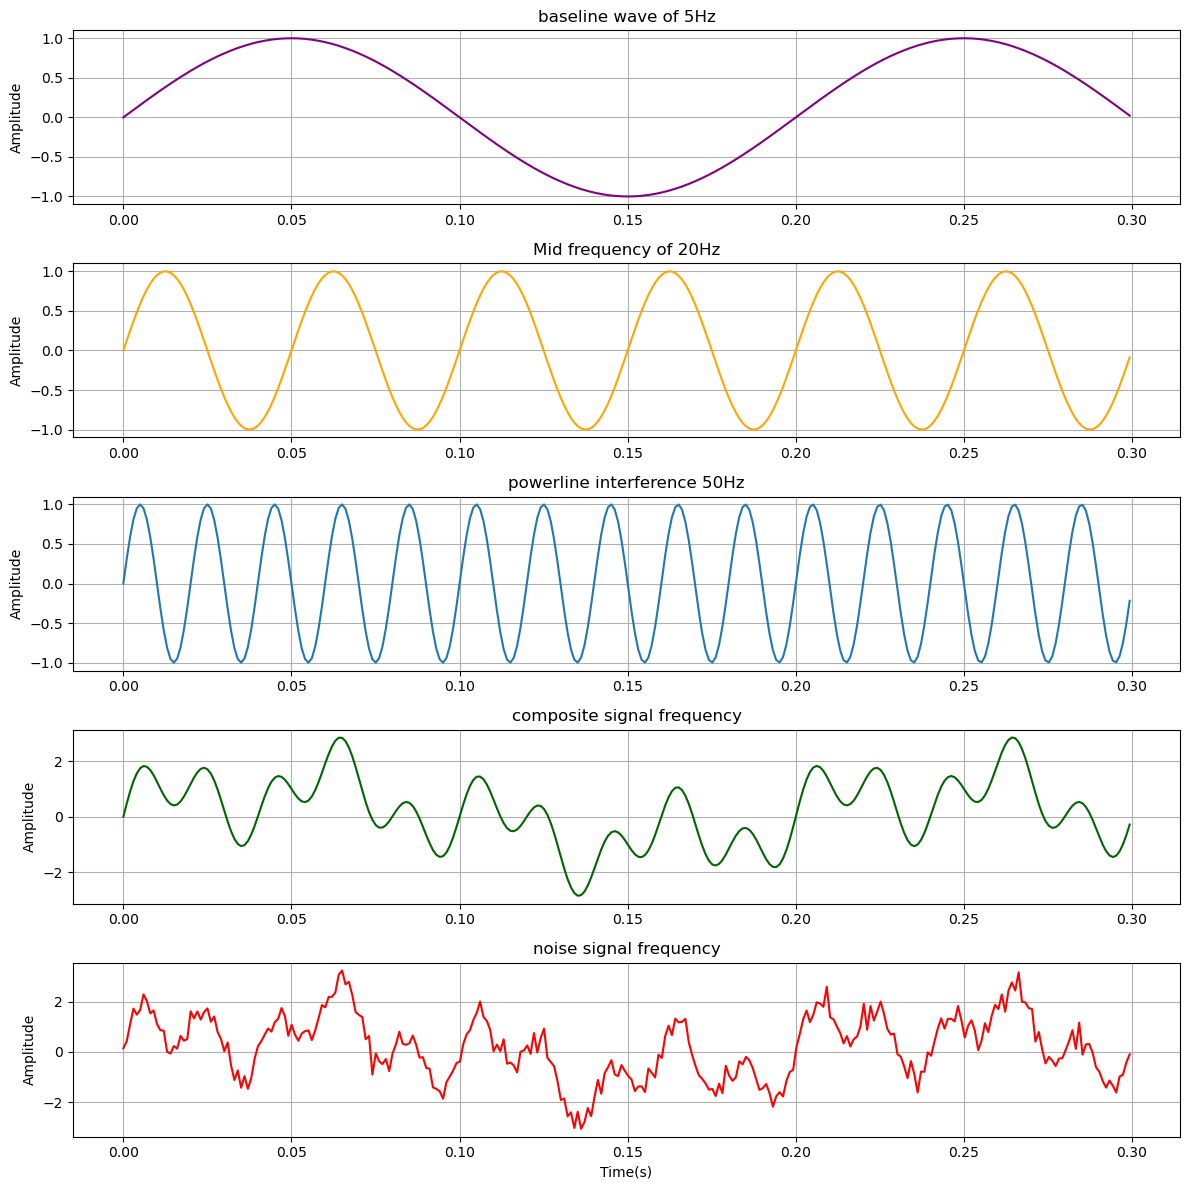

Plot saved as output_signal.png


In [3]:
# Three frequency components 
f1=5       # low frequency components(baseline)
f2=20      # mid frequency 
f3=50      # powerline interfrence 

# Individual signals
y1=np.sin(2*np.pi*f1*t)
y2=np.sin(2*np.pi*f2*t)
y3=np.sin(2*np.pi*f3*t)

# Composite clean signals
y_clean=y1+y2+y3

# Adding noise
np.random.seed(42) # for reproducibility
noise=np.random.normal(0,0.3,len(t))
y_noisy=y_clean+noise

# Plot
fig,axes = plt.subplots(5,1,figsize=(12,12))

axes[0].plot(t[:300],y1[:300],color="purple")
axes[0].set_title(f"baseline wave of {f1}Hz")
axes[0].set_ylabel("Amplitude")
axes[0].grid()

axes[1].plot(t[:300],y2[:300],color="orange")
axes[1].set_title(f"Mid frequency of {f2}Hz")
axes[1].set_ylabel("Amplitude")
axes[1].grid()

axes[2].plot(t[:300],y3[:300])
axes[2].set_title(f"powerline interference {f3}Hz")
axes[2].set_ylabel("Amplitude")
axes[2].grid()

axes[3].plot(t[:300],y_clean[:300],color="darkgreen")
axes[3].set_title(f"composite signal frequency")
axes[3].set_ylabel("Amplitude")
axes[3].grid()

axes[4].plot(t[:300],y_noisy[:300],color="red")
axes[4].set_title(f"noise signal frequency")
axes[4].set_ylabel("Amplitude")
axes[4].set_xlabel("Time(s)")
axes[4].grid()

plt.tight_layout()
plt.savefig('output_signal.png',dpi=300,bbox_inches='tight')
plt.show()

print("Plot saved as output_signal.png")

## Step 2: FFT Analysis — Seeing Inside the Signal

The FFT converts our signal from the time domain to the 
frequency domain, revealing exactly which frequencies are 
present and how strong each one is.

A perfect analysis should show three clear peaks at 5, 20, 
and 50 Hz — even when the signal looks like pure noise.

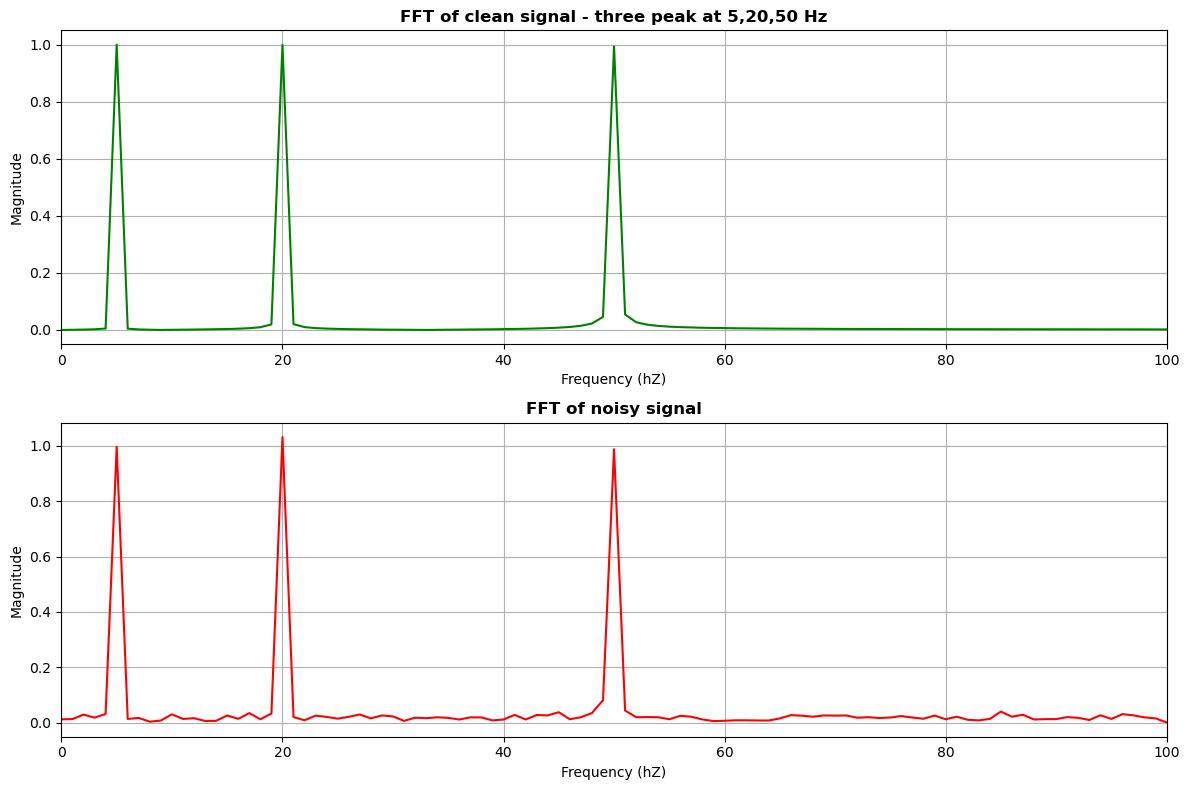

In [4]:
def fft(signal,fs,title,color="stealblue",ax=None):
    n=len(signal)   #compute and plot the FFT magnitude spectrum
    fft_values=np.fft.fft(signal)
    fft_mag= np.abs(fft_values[:n//2])*2/n
    freqs=np.fft.fftfreq(n,1/fs)[:n//2]
    if ax is None:
        fig,ax=plt.subplots(figsize=(10,4))
    ax.plot(freqs,fft_mag,color=color)
    ax.set_title(title,weight="bold")
    ax.set_xlabel("Frequency (hZ)")
    ax.set_ylabel("Magnitude")
    ax.set_xlim(0,100)
    ax.grid()
    return freqs,fft_mag

fig,axes=plt.subplots(2,1,figsize=(12,8))

fft(y_clean,fs,"FFT of clean signal - three peak at 5,20,50 Hz",color="Green",ax=axes[0])
fft(y_noisy,fs,"FFT of noisy signal","red",ax=axes[1])
plt.tight_layout()
plt.savefig("Output_FFT.png",dpi=300,bbox_inches="tight")
plt.show()





## Step 3: Digital Filtering — Removing Unwanted Components

A low-pass filter with cutoff at 30 Hz will:
- KEEP: 5 Hz and 20 Hz components (signal of interest)
- REMOVE: 50 Hz powerline interference + high-frequency noise

We use a Butterworth filter with filtfilt() for zero-phase 
filtering — critical for preserving signal timing.

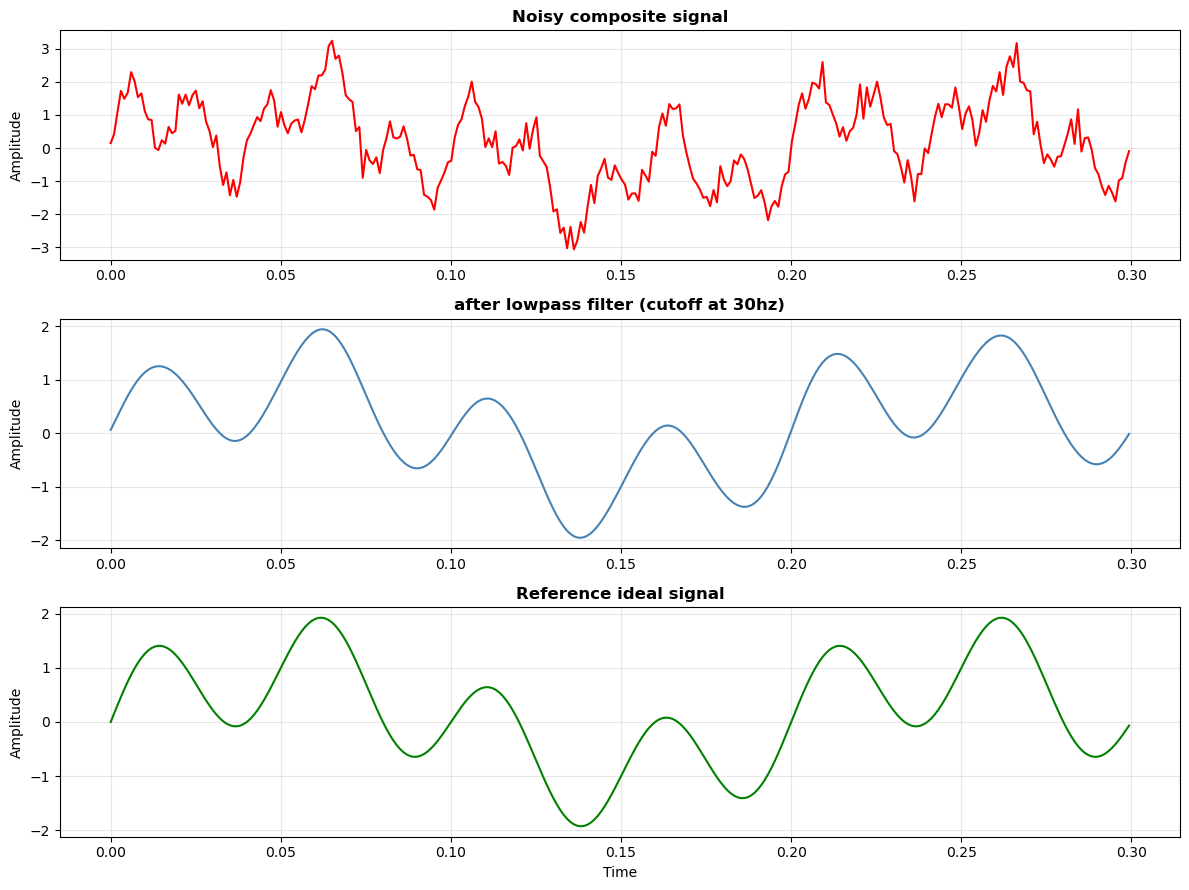

In [5]:
# Low pass Butterworth filter
cutoff=30
order=4
b,a=butter(order,cutoff,fs=fs,btype='low')

# Apply zero-phase filter
y_filtred=filtfilt(b,a,y_noisy)

# Reference signal - without 50 hz component
y_refrence=y1+y2

#plot
fig, axes = plt.subplots(3,1,figsize=(12,9))
axes[0].plot(t[:300],y_noisy[:300],color="red")
axes[0].set_title("Noisy composite signal",weight="bold")
axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.3)

axes[1].plot(t[:300],y_filtred[:300],color='steelblue')
axes[1].set_title(f"after lowpass filter (cutoff at {cutoff}hz)",weight="bold")
axes[1].set_ylabel("Amplitude")
axes[1].grid(alpha=0.3)

axes[2].plot(t[:300],y_refrence[:300],color="green")
axes[2].set_title("Reference ideal signal",weight="bold")
axes[2].set_ylabel("Amplitude")
axes[2].set_xlabel("Time")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Output filtered signal.png",dpi=300,bbox_inches='tight')
plt.show()


In [6]:
def snr(clean,noisy):
    noise=noisy-clean
    snr=10*np.log10(np.var(clean)/np.var(noise))
    return round(snr,2)
snr_before=snr(y_refrence,y_noisy)
snr_after=snr(y_refrence,y_filtred)
print(f"SNR before filter: {snr_before} dB")
print(f"SNR after filter:  {snr_after} dB")
print(f"SNR improvement:   {round(snr_after-snr_before, 2)} dB")

SNR before filter: 2.35 dB
SNR after filter:  23.38 dB
SNR improvement:   21.03 dB


## Results and Conclusions

| Metric | Value |
|--------|-------|
| Filter type | Butterworth Low-pass, Order 4 |
| Cutoff frequency | 30 Hz |
| SNR before filtering | 2.35 dB |
| SNR after filtering | 23.38 dB |
| SNR improvement | 21.03 dB |

**Key observations:**
1. FFT clearly identifies all three frequency components even 
   in the presence of noise
2. Low-pass filter successfully removes the 50 Hz powerline 
   component and reduces broadband noise
3. SNR improvement of ~21 dB is consistent with published 
   classical filter benchmarks
